<a href="https://colab.research.google.com/github/AbdulNaeemB/Lab-Assignments/blob/main/Data_Science_Fundamentals_Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
x=[1,2,3,4,5,6,7,8,9]
y=[2,3,4,5,6,7,8,9,10]

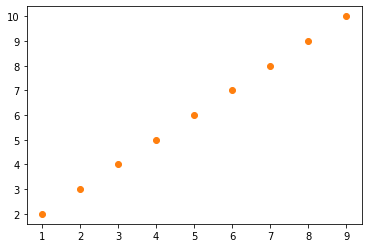

In [ ]:
plt.scatter(x,y,c='#ff7f0e')
plt.show()

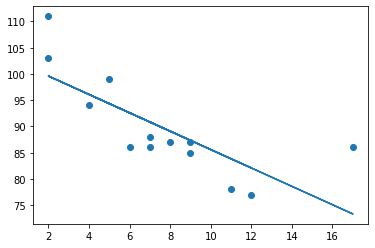

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
  return slope * x + intercept

mymodel = list(map(myfunc, x))

plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

In [ ]:
result = stats.linregress(x, y)
print(result.intercept, result.intercept_stderr,result.slope,result.rvalue,result.pvalue)

103.10596026490066 3.9034928101545123 -1.7512877115526118 -0.758591524376155 0.0026468739224561064


In [ ]:
x=10
y=slope * x + intercept
print(y)

85.59308314937454


In [ ]:
data=pd.read_csv("adult.csv")
data

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
data.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
array=data.values
X=array[:1000,:1]
y=array[:1000,1]

In [ ]:
print(array)

[[25 'Private' 226802 ... 40 'United-States' '<=50K']
 [38 'Private' 89814 ... 50 'United-States' '<=50K']
 [28 'Local-gov' 336951 ... 40 'United-States' '>50K']
 ...
 [58 'Private' 151910 ... 40 'United-States' '<=50K']
 [22 'Private' 201490 ... 20 'United-States' '<=50K']
 [52 'Self-emp-inc' 287927 ... 40 'United-States' '>50K']]


In [ ]:
from pandas import read_csv
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [ ]:
array = data.values

X_train, X_validation, Y_train, Y_validation = train_test_split(X, y, test_size=200, random_state=1)

In [ ]:
models = []


models.append(('KNN', KNeighborsClassifier()))

models.append(('CART', DecisionTreeClassifier()))

models.append(('NB', GaussianNB()))

In [ ]:
# evaluate each model in turn
results = []

names = []

for name, model in models:

  cv_results = cross_val_score(model, X_train, Y_train, scoring='balanced_accuracy')

  results.append(cv_results)

  names.append(name)

  print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

KNN: 0.164903 (0.019315)
CART: 0.160484 (0.014563)
NB: 0.147706 (0.009996)


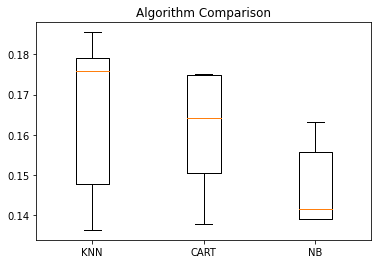

In [ ]:
pyplot.boxplot(results, labels=names)

pyplot.title('Algorithm Comparison')

pyplot.show()

In [ ]:
model = SVC(gamma='auto')

model.fit(X_train, Y_train)

predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))

print(confusion_matrix(Y_validation, predictions))

0.62
[[  0   0   0   9   0   1   0]
 [  0   0   0  10   0   0   0]
 [  0   0   0  14   0   1   0]
 [  0   0   0 123   0   3   0]
 [  0   0   0  15   0   0   0]
 [  0   0   0  14   0   1   0]
 [  0   0   0   9   0   0   0]]


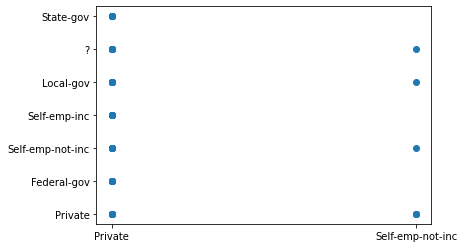

In [ ]:
plt.scatter(predictions,Y_validation)